# 乾物バンド統計特徴 × LOSO × 外挿モデル比較

乾物(C-H)バンドから統計特徴を抽出し、LOSO(Leave-One-Species-Out, macro-RMSE)で
以下のモデルを比較する。

| 種別 | モデル | 外挿 |
|---|---|---|
| 木(外挿不可) | RandomForest / LightGBM | 範囲外で天井打ち |
| 線形(外挿可) | Ridge / Huber | 直線で外挿 |
| 非線形パラメトリック(外挿可) | exp-target Ridge `MC=exp(Xβ)` / 1次元exp当てはめ `MC=A·exp(B·f)+C` | 関数形で外挿 |

注目樹種 **ベイスギ**(MC最大298%, 他樹種最大216%)=外挿が必要な極値。
全統計特徴は行単位=リーク無し。スケーラ/モデルのみ各foldの学習側でfit。

In [1]:
import numpy as np, pandas as pd
from scipy.signal import savgol_filter
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from scipy.optimize import curve_fit
import lightgbm as lgb

tr = pd.read_csv('../data/train_clean.csv', encoding='shift_jis')
META = ['sample number','species number','樹種','含水率']
wn_cols = [c for c in tr.columns if c not in META]
wn = np.array([float(c) for c in wn_cols]); wl = 1e7 / wn
order = np.argsort(wl); nm = wl[order]
X  = tr[wn_cols].values.astype(float)[:, order]
mc = tr['含水率'].values.astype(float); sp = tr['樹種'].values
species = np.unique(sp)
snv = lambda M: (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-8)
sg  = lambda M, d: savgol_filter(M, 11, 2, deriv=d, axis=1)
S, S1, S2 = snv(X), sg(snv(X),1), sg(snv(X),2)
print('train', X.shape, '| MC %.1f-%.1f%%'%(mc.min(),mc.max()))

train (1270, 1555) | MC 0.8-298.6%


## 1. 乾物バンドから統計特徴を抽出
乾物(C-H/セルロース・リグニン)バンド × 統計量。全て行単位。

In [2]:
# (チャネル, 帯域[nm]) 乾物バンド
DRY_BANDS = {
  'CH1715': (S2, 1700, 1740),
  'CH2320': (S2, 2300, 2340),
  'CH1270': (S1, 1260, 1300),
  'CL2360': (S,  2340, 2400),   # セルロース/リグニン結合音
  'CH2210': (S2, 2200, 2240),
  'CH1800': (S2, 1780, 1840),
}
def cr_depth(B):
    n=B.shape[1]; line=np.linspace(B[:,0],B[:,-1],n).T; return (line-B).max(1)
def stats(B, w):
    sl = np.polyfit(w, B.T, 1)[0]
    return {'mean':B.mean(1),'std':B.std(1),'min':B.min(1),'max':B.max(1),
            'amp':B.max(1)-B.min(1),'slope':sl,'area':B.sum(1),'crd':cr_depth(B)}
cols, names = [], []
for bn,(M,lo,hi) in DRY_BANDS.items():
    sel=(nm>=lo)&(nm<=hi); B=M[:,sel]; w=nm[sel]
    for st,v in stats(B,w).items():
        cols.append(v); names.append(f'{bn}|{st}')
F = np.column_stack(cols)
print('特徴行列 F:', F.shape, '=', len(DRY_BANDS),'バンド ×8統計量')

特徴行列 F: (1270, 48) = 6 バンド ×8統計量


## 2. モデル定義(外挿モデル含む)

In [3]:
def rf():    return RandomForestRegressor(400, random_state=42, n_jobs=-1)
def gbm():   return lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03,
                                      num_leaves=15, random_state=42, verbose=-1)
def ridge(): return make_pipeline(StandardScaler(), Ridge(alpha=1.0))
def huber(): return make_pipeline(StandardScaler(), HuberRegressor(alpha=1.0, max_iter=500))
# exp-target線形: MC=exp(Xβ) を学習(単調・指数外挿)。logでfit→expで逆変換。
def exp_ridge():
    return TransformedTargetRegressor(make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
                                      func=np.log, inverse_func=np.exp)

# 1次元 非線形当てはめ: MC = A·exp(B·f)+C を最有力特徴1本で。
BEST = names.index('CH1715|mean')
class ExpCurve1D:
    def __init__(self, idx=BEST): self.idx=idx
    def fit(self, Xtr, y):
        f=Xtr[:,self.idx]
        p0=[y.std(), 1.0/(f.std()+1e-6), y.min()]
        try: self.p,_=curve_fit(lambda x,A,B,C:A*np.exp(B*x)+C, f, y, p0=p0, maxfev=20000)
        except Exception: self.p=np.polyfit(f,y,1)  # 失敗時は線形
        return self
    def predict(self, Xte):
        f=Xte[:,self.idx]
        if len(self.p)==3: A,B,C=self.p; return np.clip(A*np.exp(B*f)+C,0,400)
        return np.polyval(self.p,f)
MODELS = {'RandomForest':rf,'LightGBM':gbm,'Ridge':ridge,'Huber':huber,
          'exp-Ridge MC=exp(Xβ)':exp_ridge,'exp-1D MC=Aexp(Bf)+C':lambda:ExpCurve1D()}
print('モデル:', list(MODELS))

モデル: ['RandomForest', 'LightGBM', 'Ridge', 'Huber', 'exp-Ridge MC=exp(Xβ)', 'exp-1D MC=Aexp(Bf)+C']


## 3. LOSO検証(macro-RMSE)

In [4]:
def loso(model_fn):
    per={}
    for s in species:
        te=sp==s; trn=~te
        m=model_fn(); m.fit(F[trn], mc[trn])
        p=np.asarray(m.predict(F[te])).ravel()
        per[s]=np.sqrt(np.mean((p-mc[te])**2))
    return per

res={}
for mn,mf in MODELS.items():
    per=loso(mf); res[mn]=per
    print(f'{mn:24s} macro={np.mean(list(per.values())):6.2f}  ベイスギ={per["ベイスギ"]:6.1f}')

RandomForest             macro= 23.04  ベイスギ=  83.7


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM                 macro= 24.69  ベイスギ=  82.9
Ridge                    macro= 23.17  ベイスギ=  82.1


Huber                    macro= 19.50  ベイスギ=  77.6
exp-Ridge MC=exp(Xβ)     macro= 22.58  ベイスギ=  62.3
exp-1D MC=Aexp(Bf)+C     macro= 29.09  ベイスギ=  56.3


In [5]:
tbl = pd.DataFrame(res).T
tbl.insert(0,'macro', tbl.mean(1))
tbl = tbl.sort_values('macro')
cols_show = ['macro','ベイスギ','イチョウ','米ヒバ','クリ','ヒノキ','ナラ','トチ']
display(tbl[cols_show].round(1))

,macro,ベイスギ,イチョウ,米ヒバ,クリ,ヒノキ,ナラ,トチ
Huber,19.5,77.6,21.2,13.4,8.9,10.3,14.9,11.5
exp-Ridge MC=exp(Xβ),22.6,62.3,32.2,19.6,13.9,11.1,17.7,7.1
RandomForest,23.0,83.7,23.3,24.0,12.1,15.7,9.9,6.6
Ridge,23.2,82.1,33.8,12.8,11.4,15.0,10.4,10.6
LightGBM,24.7,82.9,28.4,25.1,14.0,14.1,9.4,4.8
exp-1D MC=Aexp(Bf)+C,29.1,56.3,30.2,24.3,39.5,30.3,7.7,8.1


## 4. ベイスギfold: 真値 vs 予測(外挿できているか)
木モデルは天井打ち(対角線上で頭打ち)、外挿モデルは高MCまで伸びるかを可視化。

/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


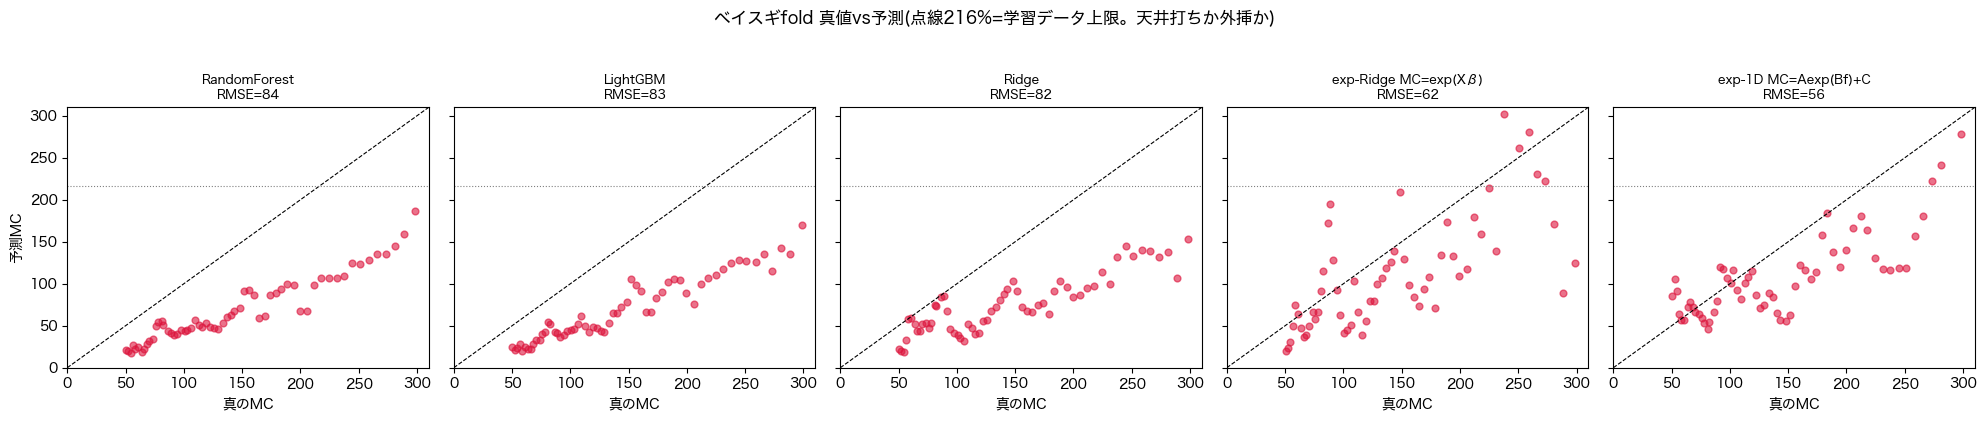

In [6]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['font.family']=['Hiragino Sans','AppleGothic','sans-serif']
matplotlib.rcParams['axes.unicode_minus']=False
ced=sp=='ベイスギ'
show=['RandomForest','LightGBM','Ridge','exp-Ridge MC=exp(Xβ)','exp-1D MC=Aexp(Bf)+C']
fig, ax=plt.subplots(1,len(show), figsize=(4*len(show),4), sharex=True, sharey=True)
for a,mn in zip(ax,show):
    m=MODELS[mn](); m.fit(F[~ced], mc[~ced]); p=np.asarray(m.predict(F[ced])).ravel()
    a.scatter(mc[ced], p, s=24, alpha=.6, c='crimson')
    lim=[0,310]; a.plot(lim,lim,'k--',lw=.8); a.set_xlim(lim); a.set_ylim(lim)
    a.axhline(216,color='gray',ls=':',lw=.8)  # 学習データのMC上限
    a.set_title(f'{mn}\nRMSE={res[mn]["ベイスギ"]:.0f}', fontsize=9)
    a.set_xlabel('真のMC')
ax[0].set_ylabel('予測MC')
plt.suptitle('ベイスギfold 真値vs予測(点線216%=学習データ上限。天井打ちか外挿か)', y=1.04)
plt.tight_layout(); plt.show()